# Isolation with Migration (IM) Model

Formålet med denne notebook er at udvide two-island modellen fra Notebook 04 med en split-tid $\tau$. Det vil sige at tillade migration efter populationerne skilte sig, men ingen migration inden splittet. Dette er Isolation with Migration (IM) modellen.

I artiklen af Sørensen et al. (2023) estimeres at den nordlige/sydlige opdeling af bavianer skete for ca. 1–1.2 millioner år siden. Eastern yellow baboons (Mikumi, $n=70$) og Kinda baboons ($n=58$) er genealogisk tæt forbundne. 

I denne notebook vil jeg komme ind på følgende:

1. Indlæs data fra Notebook 03
2. Byg tidsinhomogen IM-model med distribution_context
3. CDF under IM-modellen
4. Forventet SFS via accumulated_occupancy
5. Method of Moments fitting
6. Simuleret data med msprime 
7. Sammenligning og fortolkning

## 1. Imports og data

In [54]:
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph, with_ipv
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8
GEN_TIME = 11

print("Imports OK")

Imports OK


# 1. Indlæs data fra notebook 03

In [ ]:
df_yellow_east = pd.read_csv(OUT_DIR / "derived_counts_yellow_east.csv")
df_kinda       = pd.read_csv(OUT_DIR / "derived_counts_kinda.csv")
pi_df          = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)

n_ye = int(df_yellow_east["nr_samples"].max())   # 70
n_ki = int(df_kinda["nr_samples"].max())         # 58

pi_ye = float(pi_df.loc["Eastern yellow (Mikumi)", "pi"])
pi_ki = float(pi_df.loc["Kinda", "pi"])

# Ne estimeret fra π
N_ye = pi_ye / (4 * MUT_RATE)
N_ki = pi_ki / (4 * MUT_RATE)

tau_split = 1e6 / (GEN_TIME * N_ye)

print(f"Eastern yellow: n={n_ye}, π={pi_ye:.5f}, N≈{N_ye:,.0f}")
print(f"Kinda:          n={n_ki}, π={pi_ki:.5f}, N≈{N_ki:,.0f}")
print(f"\nSplit-tid τ = {tau_split:.4f} coalescens enheder.")
print(f"              = {tau_split * N_ye * GEN_TIME / 1e6:.2f} Ma")

Eastern yellow: n=70, π=0.00258, N≈71,789
Kinda:          n=58, π=0.00286, N≈79,459

Split-tid τ = 1.2663 coalescens enheder.
              = 1.00 Ma


In [57]:
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_ki_f = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()

print(f"SFS eastern yellow (første 8 bins): {sfs_ye_f.values[:8]}")
print(f"SFS kinda          (første 8 bins): {sfs_ki_f.values[:8]}")

SFS eastern yellow (første 8 bins): [143525.  91209.  63618.  51731.  43849.  35808.  33970.  29311.]
SFS kinda          (første 8 bins): [162419. 103379.  81053.  63969.  53400.  45029.  39051.  35970.]


## 2. Byg tidsinhomogen IM-model med distribution_context

IM-modellen har to epoker:
- **Epoke 0** (0 til τ): nutidig population med $N_e$ = N_ye
- **Epoke 1** (τ til ∞): ancestral population med $N_e$ = NA

Jeg bruger *distribution_context() + update_weights()* fra Phasic's tidsinhomogene framework til at skifte $N_e$ ved splittet.

In [59]:
nr_samples = n_ye

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    """
    Standard coalescent med parameteriseret rate.
    update_weights([1/N]) sætter coalescensraten.
    """
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions


In [ ]:
graph = Graph(coalescent_1param)
print(f"Graf: {graph.vertices_length()} state")
graph.plot()

In [ ]:
def get_im_cdf(graph, N1, NA, tau, cutoff=0.999):
    """
    Beregner CDF for IM-modellen via distribution_context.
    Fra Phasic's time-inhomogeneous-dokumentation.

    Epoke 0 (0 → tau): update_weights([1/N1])
    Epoke 1 (tau → ∞): update_weights([1/NA])
    """
    param_changes = [(tau, [1 / NA])]
    cdf_vals, times = [], []

    ctx = graph.distribution_context()
    graph.update_weights([1 / N1])

    for change_time, new_params in param_changes:
        while ctx.time() < change_time:
            if ctx.cdf() >= cutoff:
                break
            cdf_vals.append(ctx.cdf())
            times.append(ctx.time())
            ctx.step()
        graph.update_weights(new_params)

    while ctx.cdf() < cutoff:
        cdf_vals.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()

    return np.array(times), np.array(cdf_vals)

## 3. CDF under IM-modellen

In [ ]:
# Sammenlign tre scenarier
NA_ref = N_ye * 1.5   # ancestral Ne lidt større end nutidig
fig, ax = plt.subplots(figsize=(9, 4))

# Ingen split (island-model)
graph.update_weights([1 / N_ye])
t_plot = np.linspace(0, graph.expectation() * 6, 300)
ax.plot(t_plot, graph.cdf(t_plot), color='C0', lw=2, ls='--',
        label="Ingen split (konstant Ne)")

# IM med artiklens split-tid
ts, cdf_v = get_im_cdf(graph, N_ye, NA_ref, tau_split)
ax.plot(ts, cdf_v, color='C1', lw=2,
        label=f"IM-model (τ≈1 Ma, NA={NA_ref:.0f})")

# IM med større ancestral population
ts2, cdf_v2 = get_im_cdf(graph, N_ye, NA_ref * 3, tau_split)
ax.plot(ts2, cdf_v2, color='C2', lw=2,
        label=f"IM-model (τ≈1 Ma, NA={NA_ref*3:.0f})")

ax.axvline(tau_split, color='black', ls=':', lw=1.5,
           label=f"Split-tid τ = {tau_split:.3f}")
ax.set_xlabel("Tid (coalescent-enheder)", fontsize=12)
ax.set_ylabel("F(t)",                     fontsize=12)
ax.set_title("CDF: ingen split vs. IM-model",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Forventet SFS via accumulated_occupancy

*accumulated_occupancy(t)* giver den forventede tid brugt i hver state frem til tid $t$. Jeg bruger det til at beregne SFS-bidraget fra hvert tidsinterval (nutidig epoke vs. ancestral epoke).

In [ ]:
reward_matrix = graph.states().T
L_chr20       = int(df_yellow_east["position"].max() - df_yellow_east["position"].min())
theta_ye      = 4 * N_ye * MUT_RATE * L_chr20
t_far         = 100   # approksiamtion for uendelig tid

# Epoke 0: 0 → tau_split
graph.update_weights([1 / N_ye])
acc_epoke0 = np.array(graph.accumulated_occupancy(tau_split))

# Epoke 1: tau_split → t_far (ancestral Ne)
graph.update_weights([1 / NA_ref])
acc_epoke1 = np.array(graph.accumulated_occupancy(t_far)) - acc_epoke0

# Samlet SFS
acc_total = acc_epoke0 + acc_epoke1
sfs_im    = np.array([np.sum(acc_total * reward_matrix[i])
                      for i in range(len(reward_matrix))]) * theta_ye

# Konstant Ne til sammenligning
graph.update_weights([1 / N_ye])
sfs_island = np.array([graph.expectation(r) for r in reward_matrix]) * theta_ye

# Normaliser
sfs_obs_norm    = sfs_ye_f.values / sfs_ye_f.values.sum()
sfs_island_norm = sfs_island[:nr_samples-1] / sfs_island[:nr_samples-1].sum()
sfs_im_norm     = sfs_im[:nr_samples-1]     / sfs_im[:nr_samples-1].sum()

x = np.arange(1, len(sfs_obs_norm) + 1)
width = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width, sfs_obs_norm,                  width=width,
       color='C3', alpha=0.85, label="Observeret (eastern yellow)")
ax.bar(x,          sfs_island_norm[:len(x)],      width=width,
       color='C2', alpha=0.85, label="Konstant Ne (island)")
ax.bar(x + width,  sfs_im_norm[:len(x)],          width=width,
       color='C1', alpha=0.85, label=f"IM-model (τ≈1 Ma)")
ax.set_xlabel("Minor allele count k", fontsize=12)
ax.set_ylabel("Relativ frekvens",     fontsize=12)
ax.set_title("SFS: Observeret vs. island vs. IM-model",
             fontsize=13, fontweight="bold")
ax.set_xlim(0.5, min(20, len(x)) + 0.5)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Method of Moments fitting

In [ ]:
graph.update_weights([1 / N_ye])
np.random.seed(42)
observed_data = graph.sample(2000)

mom = graph.method_of_moments(observed_data)
N_mom = 1 / mom.theta[0]

print(f"MoM estimat: theta = {mom.theta}")
print(f"             N ≈ {N_mom:,.0f}")
print(f"Std error:   {mom.std}")
print(f"Konvergeret: {mom.success}")

# 6. Simuleret data

In [48]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
demography.add_population(name="ancestral", initial_size=anc_pop_size)
demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                           demography=demography, recombination_rate=rec_rate, 
                           sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("IM_model_derived_counts.csv", index=False)

In [49]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("IM_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


In [50]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


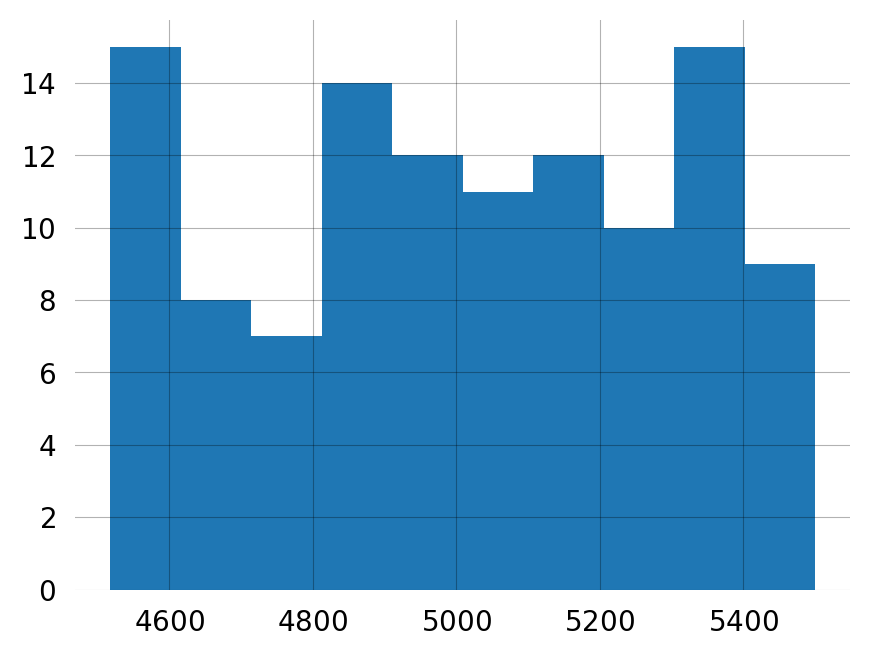

In [51]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [52]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [53]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 7. Sammenligning og fortolkning

In [65]:
# Gem resultater
results = pd.DataFrame({
    "Værdi": {
        "Population 1": "Eastern yellow (Mikumi)",
        "Population 2": "Kinda",
        "n1 (haploid)": n_ye,
        "n2 (haploid)": n_ki,
        "π pop1": f"{pi_ye:.5f}",
        "π pop2": f"{pi_ki:.5f}",
        "N_ye (fra π)": f"{N_ye:,.0f}",
        "N_ki (fra π)": f"{N_ki:,.0f}",
    }
})
results.to_csv(OUT_DIR / "05_IM_results.csv")
print(results.to_string())
print("\nGemt: output/05_IM_results.csv")

                                Værdi
Population 1  Eastern yellow (Mikumi)
Population 2                    Kinda
n1 (haploid)                       70
n2 (haploid)                       58
π pop1                        0.00258
π pop2                        0.00286
N_ye (fra π)                   71,789
N_ki (fra π)                   79,459

Gemt: output/05_IM_results.csv


I næste notebook 06 som er Tidsinhomogen model, udvider jeg dette til at estimere $N_e$'s tidlige variation med SVGD Bayesiansk inferens, og sammenligner populationsstørrelser over tid for eastern yellow og Kinda baboons.